# Borehole8


The Borehole function is a height-dimensional function, often used in Bayesian optimization, which models water flow through a borehole. The computational domain is defined as 
\begin{multline*}
\Omega = [0.05,0.15] \times [100,5\times 10^4] \times [6.307\times 10^4, 1.156\times 10^{5}] \times [990,1110] \\\times [63.1,116] \times [700,820] \times [1120,1680] \times [9855,12045].
\end{multline*}
As used in \cite{kandasamy2019}, two fidelity levels are considered and defined by 
Two fidelity levels are considered, defined by
\begin{align*}
f^{(1)}(\boldsymbol{x}) &= 
\frac{2\pi\, x_3 (x_4 - x_6)}
{\ln(x_2/x_1)\left(1 + \frac{2 x_7 x_3}{\ln(x_2/x_1)\, x_1^2 x_8} + \frac{x_3}{x_8}\right)},\\
f^{(0)}(\boldsymbol{x}) &= 
\frac{5\, x_3 (x_4 - x_6)}
{\ln(x_2/x_1)\left(1.5 + \frac{2 x_7 x_3}{\ln(x_2/x_1)\, x_1^2 x_8} + \frac{x_3}{x_8}\right)}, \\
\end{align*}
where $f^{(1)}$ is the classical Borehole function. No constraints are considered, following the standard benchmark setting in the literature.


## Imports

In [1]:
import sys, os
sys.path.insert(0, os.getcwd()) #equivalent to " export PYTHONPATH="$PWD:$PYTHONPATH" "

In [2]:
from mfscbo.functions import Borehole8
from mfscbo.mfscbo_optimization import ScboMfOptimizer
from mfscbo.plot import plot_rhos, plot_noises, plot_bestYs, plot_nbiters, plot_tr_lengths
from mfscbo.utils import eval_fun_unnormalized
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Problem setup

In [3]:
# Define torch arguments
torchargs = {
    "device": "cpu",
    "dtype": torch.double
}

In [4]:
# Define evaluation objectives 
f0_ = Borehole8(fidelity=0, torchargs=torchargs)
f1_ = Borehole8(fidelity=1, torchargs=torchargs)

# Define bounds and dimension
bounds = f0_.bounds
dim = bounds.shape[1]

# Rewrite as maximization pb because of scbo (and unnormalize)
f0 = lambda x : -eval_fun_unnormalized(x, f0_, bounds) #shape (N, 1)
f1 = lambda x : -eval_fun_unnormalized(x, f1_, bounds) #shape (N, 1)
eval_objectives = [f0, f1]

In [5]:
constraints = lambda x : (x[:,0]*0)[:, None] #no constraints, shape (N, 1)

In [6]:
# Define number of initial points, rhos and costs
n_pts = [28, 4] #total 4*dim =28+4=32
rhos = [1, 1]
costs = [1, 20]

## Optimization

In [7]:
# Initialize and run the SCBO optimizer
optimizer = ScboMfOptimizer(
    eval_objectives=eval_objectives,
    constraints=constraints,
    rhos=rhos,
    costs=costs,
    dim=dim,
    n_pts=n_pts,
    bounds=bounds,
    type_of_batch="parallel",
    type_of_centering="evaluated",
    torchargs=torchargs,
    restart=True,
    test=True,  # Predictive mode
)
optimizer.initialize()
optimizer.optimize(max_cost=2000, batch_size=8, path="results/Borehole8", verbose=True)

Starting MF-SCBO optimization...
Max cost : 2000
Batch size : 8
Path : results/Borehole8

======================================================== Parameters for MF-SCBO Optimization =========================================================
______________________________________________________________________________________________________________________________________________________
| Parameter         | Value                                                                                                                          |
------------------------------------------------------------------------------------------------------------------------------------------------------
| dim               | 8                                                                                                                              |
| bounds            | [[0.05, 100.0, 63070.0, 990.0, 63.1, 700.0, 1120.0, 9855.0], [0.15, 50000.0, 115600.0, 1110.0, 116.0, 820.0, 1680.0, 12045.0]] |
| nb

(tensor([5.0140e-02, 4.3455e+04, 1.0523e+05, 9.9014e+02, 1.1390e+02, 8.1905e+02,
         1.6501e+03, 9.9504e+03], dtype=torch.float64),
 -8.141058413295607)

## Post process

In [8]:
# Load results
data = np.load("results/Borehole8/MFSCBO_data.npz", allow_pickle=True)
gps_info = data["gps_info"]
iterations = data["iterations"]
xvalues = data["cost_iter"]
bestY = -data["best_Y"] #for minimization plot
best_C = data["best_C"]
nbiters = data["nb_iter"]
tr_lengths = data["trust_region_lengths"]

In [9]:
# Post-process bestY when constraints are not respected 
best_violated_C = np.sum(np.maximum(0, best_C), axis=1)
bestY = np.array(bestY, dtype=np.float64)
running_max = np.max(bestY)
bestY = np.where(best_violated_C > 0, running_max, bestY)

# Post-process rhos
rhos = [[1] for _ in range(len(gps_info)-1)]  # no rho for fidelity 0
for fid in range(1, len(gps_info)):
    for it in range(len(iterations)-1):
        rhos[fid-1].append(gps_info[fid][it]["rho"])

# Post-process noises
noises = [[] for _ in range(len(gps_info))]
for fid in range(len(gps_info)):
    for it in range(len(iterations)-1):
        noises[fid].append(gps_info[fid][it]["noise"])

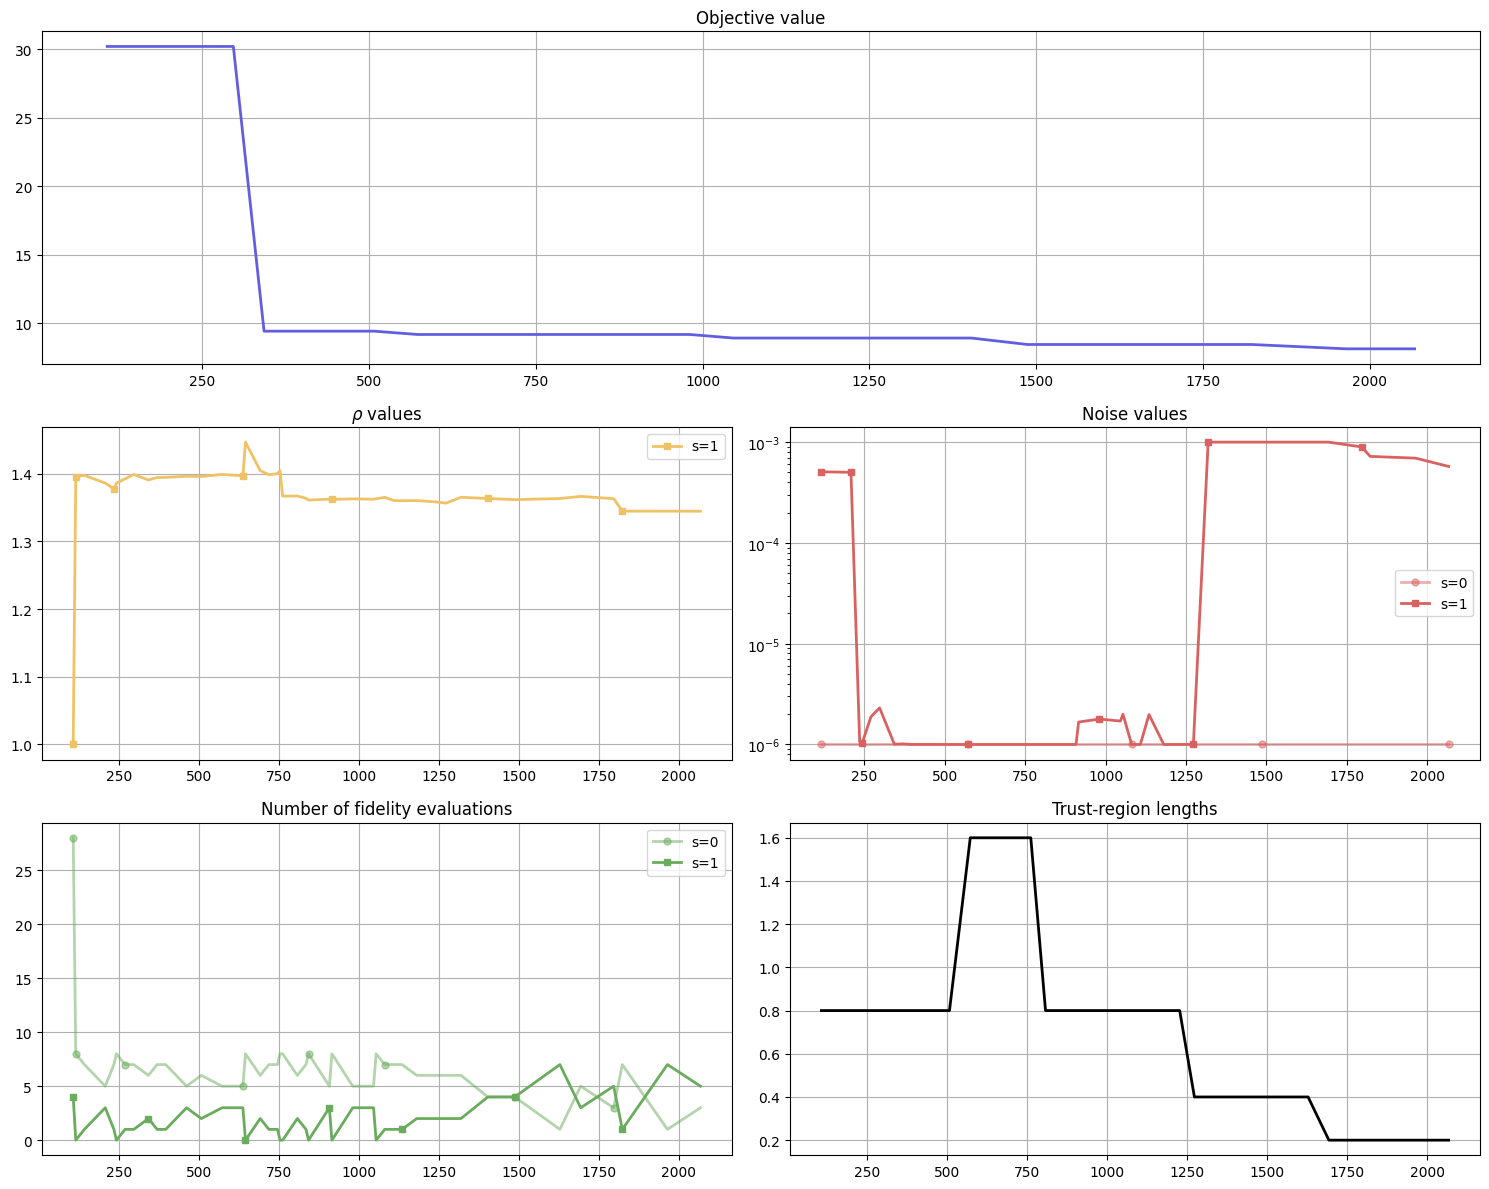

In [10]:
# Plot results
fig = plt.figure(figsize=(15, 12))
gs = GridSpec(3, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

plot_bestYs(bestY, xvalues, ax=ax1)
plot_rhos(rhos, xvalues, ax=ax2)
plot_noises(noises, xvalues[1:], ax=ax3)
plot_nbiters(nbiters, xvalues, ax=ax4)
plot_tr_lengths(tr_lengths, xvalues, ax=ax5)

# Set titles, legends, and grids
ax1.set_title("Objective value")
ax1.grid()
ax2.set_title(r"$\rho$ values")
ax2.legend()
ax2.grid()
ax3.set_title("Noise values")
ax3.legend()
ax3.grid()
ax3.set_yscale("log")
ax4.set_title("Number of fidelity evaluations")
ax4.legend()
ax4.grid()
ax5.set_title("Trust-region lengths")
ax5.grid()

plt.tight_layout()
plt.savefig("results/Borehole8/MFSCBO_plots.pdf")
plt.show()